### Bonus Solution: Improving a Local Search

This task is meant to be more open-ended. To get things started let's first run the setup code below.

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
plt.rcParams["animation.embed_limit"] = 100.0

np.random.seed(2109)

n = 100
points = np.random.randint(0, 100, size=(n, 2))


def get_angle(a, b, c):
    ba = a - b
    bc = c - b
    dot = np.dot(ba, bc)
    norm_ba = np.dot(ba, ba)
    norm_bc = np.dot(bc, bc)
    if norm_ba == 0 or norm_bc == 0:
        return 180.0
    cos_theta = dot / np.sqrt(norm_ba * norm_bc)
    cos_theta = np.clip(cos_theta, -1.0, 1.0)
    angle_rad = np.arccos(cos_theta)
    return np.degrees(angle_rad)


def get_min_angle(perm):
    route = points[perm]
    min_angle = 180.0
    for i in range(1, n - 1):
        a, b, c = route[i - 1], route[i], route[i + 1]
        angle = get_angle(a, b, c)
        min_angle = min(min_angle, angle)
    return min_angle


def plot_graph_init():
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_title("Hill Climbing Optimization of Route")
    ax.axis("equal")
    ax.grid(True)

    xmin, xmax = points[:, 0].min(), points[:, 0].max()
    ymin, ymax = points[:, 1].min(), points[:, 1].max()
    pad_x = (xmax - xmin) * 0.05 + 1
    pad_y = (ymax - ymin) * 0.05 + 1
    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)

    scat = ax.scatter(points[:, 0], points[:, 1], color='blue', s=40, alpha=0.8)
    arrows = ax.quiver(
        np.zeros(n-1), np.zeros(n-1),
        np.zeros(n-1), np.zeros(n-1),
        angles='xy', scale_units='xy', scale=1,
        color='black', width=0.004, alpha=0.8
    )
    text = ax.text(0.02, 0.95, "", transform=ax.transAxes, fontsize=12, va="top")

    return fig, ax, scat, arrows, text


def update_plot(frame_data, line, text):
    perm, value = frame_data
    route = points[perm]
    dx = route[1:, 0] - route[:-1, 0]
    dy = route[1:, 1] - route[:-1, 1]
    arrows.set_offsets(route[:-1])
    arrows.set_UVC(dx, dy)
    text.set_text(f"Min Angle: {value:.2f}°")
    # return a tuple/list of artists that changed
    return arrows, text

def hill_climbing(init_perm, max_iter=100, n_neighbours=100):    
    current_perm = init_perm.copy()
    current_value = get_min_angle(current_perm)
    yield current_perm, current_value

    for step in range(max_iter):
        improved = False
        best_local_perm = None
        best_local_value = current_value

        for _ in range(n_neighbours):
            i, j = np.random.randint(0, n, size=2)
            if i == j:
                continue
            new_perm = current_perm.copy()
            new_perm[i], new_perm[j] = new_perm[j], new_perm[i]
            new_value = get_min_angle(new_perm)

            if new_value > best_local_value:
                best_local_value = new_value
                best_local_perm = new_perm
                improved = True

        if improved:
            current_perm = best_local_perm
            current_value = best_local_value
            yield current_perm, current_value

        if step % 10 == 9:
            print(f"Step {step}, Current Value: {current_value}")

        if not improved:
            break


Here are my 3 (!) solutions.

Upon inspecting the output of the given hill climbing implementation, you would notice that the hill
climbing terminates very early. This is because the evaluation function never improved among all 100
neighbours considered. This comes from two potential causes:

- The evaluation function takes the **minimum** angle among all $N−2$ checkpoints. Therefore, the
value will not improve unless we change that particular checkpoint (or its neighbours). Therefore,
improving the evaluation function is rare and very restricted.
- The search may be stuck in a local minima.

Given the observation that the evaluation function usually stays the same, we can change the hill climbing
algorithm to accept tied evaluation functions (basically, accept `new_value >= best_local_value` instead
of strictly `>`). This should give you a minimum angle of $≈41◦$ within 1 minute.

In [ ]:
def hill_climbing(init_perm, max_iter=100, n_neighbours=100):    
    current_perm = init_perm.copy()
    current_value = get_min_angle(current_perm)
    yield current_perm, current_value

    for step in range(max_iter):
        improved = False
        best_local_perm = None
        best_local_value = current_value

        for _ in range(n_neighbours):
            i, j = np.random.randint(0, n, size=2)
            if i == j:
                continue
            new_perm = current_perm.copy()
            new_perm[i], new_perm[j] = new_perm[j], new_perm[i]
            new_value = get_min_angle(new_perm)

            # Changed from > to >= to allow equal-value moves
            if new_value >= best_local_value:
                best_local_value = new_value
                best_local_perm = new_perm
                improved = True

        if improved:
            current_perm = best_local_perm
            current_value = best_local_value
            yield current_perm, current_value

        if step % 10 == 9:
            print(f"Step {step}, Current Value: {current_value}")

        if not improved:
            break
        

In [ ]:
%%time
np.random.seed(2109)
init_perm = np.random.permutation(n)
fig, ax, scat, arrows, text = plot_graph_init()
gen = hill_climbing(init_perm)
ani = FuncAnimation(fig, update_plot, frames=gen, fargs=(arrows, text),
                    interval=250, blit=True, repeat=False, cache_frame_data=False)
plt.close(fig)
HTML(ani.to_jshtml())

One potential improvement is to accept worst-off solutions with an acceptance probability (i.e. simulated
annealing). With initial temperature = 0.1, alpha = 0.9999 and 10,000 iterations, you should be able to
attain a minimum angle of $≈54◦$ within 1 minute.


The `hill_climbing` function should look like the following:

In [ ]:
def hill_climbing(init_perm, max_iter=10000, n_neighbours=100):    
    current_perm = init_perm.copy()
    current_value = get_min_angle(current_perm)
    yield current_perm, current_value

    temp = 0.1
    alpha = 0.9999
    best_perm = current_perm # keep track of best permutation found
    best_value = current_value # keep track of best value found

    for step in range(max_iter):
        improved = False
        i, j = np.random.randint(0, n, size=2)
        if i == j:
            continue

        new_perm = current_perm.copy()
        new_perm[i], new_perm[j] = new_perm[j], new_perm[i]

        new_value = get_min_angle(new_perm)
        delta = new_value - current_value

        if delta > 0 or np.random.rand() < np.exp(delta / temp):
            current_perm = new_perm
            current_value = new_value
            if delta > 0:
                best_perm = new_perm
                best_value = new_value
                improved = True

        if improved:
            yield current_perm, current_value

        if step % 10 == 9:
            print(f"Step {step}, Current Value: {current_value}")

        temp *= alpha


In [ ]:
%%time
np.random.seed(2109)
init_perm = np.random.permutation(n)
fig, ax, scat, arrows, text = plot_graph_init()
gen = hill_climbing(init_perm)
ani = FuncAnimation(fig, update_plot, frames=gen, fargs=(arrows, text),
                    interval=250, blit=True, repeat=False, cache_frame_data=False)
plt.close(fig)
HTML(ani.to_jshtml())

To do even better, we should try to change the evaluation function. The current loophole of the evaluation
function is that it doesn’t give much information other than the checkpoint that gives the minimum angle.
What if we change the evaluation function to compare the **10 smallest angles** instead?

In [ ]:
def custom_eval(perm):
    route = points[perm]
    angles = []

    for i in range(1, n - 1):
        a, b, c = route[i - 1], route[i], route[i + 1]
        angle = get_angle(a, b, c)
        angles.append(angle)

    angles.sort()
    return tuple(angles[:10])

With the hill climbing accepting ties, this evaluation function would be able to give you a minimum angle
of $≈61◦$ within 1 minute.

In [ ]:
def hill_climbing(init_perm, max_iter=100, n_neighbours=100):    
    current_perm = init_perm.copy()
    # Use custom evaluation function
    current_value = custom_eval(current_perm)
    yield current_perm, current_value[0]

    for step in range(max_iter):
        improved = False
        best_local_perm = None
        best_local_value = current_value

        for _ in range(n_neighbours):
            i, j = np.random.randint(0, n, size=2)
            if i == j:
                continue
            new_perm = current_perm.copy()
            new_perm[i], new_perm[j] = new_perm[j], new_perm[i]
            # Use custom evaluation function
            new_value = custom_eval(new_perm)

            # Changed from > to >= to allow equal-value moves
            if new_value >= best_local_value:
                best_local_value = new_value
                best_local_perm = new_perm
                improved = True

        if improved:
            current_perm = best_local_perm
            current_value = best_local_value
            yield current_perm, current_value[0]

        if step % 10 == 9:
            print(f"Step {step}, Current Value: {current_value}")

        if not improved:
            break

In [ ]:
%%time
np.random.seed(2109)
init_perm = np.random.permutation(n)
fig, ax, scat, arrows, text = plot_graph_init()
gen = hill_climbing(init_perm)
ani = FuncAnimation(fig, update_plot, frames=gen, fargs=(arrows, text),
                    interval=250, blit=True, repeat=False, cache_frame_data=False)
plt.close(fig)
HTML(ani.to_jshtml())

By now, you might have realized that the quality of the solution keeps improving over the 1 minute and it
has not converged yet. This signals us to increase the number of iterations. To actually do this, we would
have to make the evaluation function faster (to fit into the 1 minute time limit!).

Notice that we only swap two values in `perm`, so not many angles should be affected. The idea is to **only**
compute the angles around the affected checkpoints, before and after the swap. As we are only interested
in improving the smallest angles, we should compare two neighbours by first comparing the smallest affected angle **before the swap** (the smaller, the better), followed by the smallest affected angle **after the swap** (the larger, the better). Of course, we should discard solutions that made the angles smaller.

This code runs much faster as expected. We can explore 1000 neighbours per iteration but still complete
100 iterations within the time limit, leading to a solution with minimum angle $≈63◦$.

The evaluation function will look like the following:

In [ ]:
def fast_eval(perm, i, j):
    affected = set([i - 1, i, i + 1, j - 1, j, j + 1])
    min_angle = 180.0

    for idx in affected:
        if idx < 1 or idx >= n - 1:
            continue
        a, b, c = points[perm[idx - 1]], points[perm[idx]], points[perm[idx + 1]]
        angle = get_angle(a, b, c)
        min_angle = min(min_angle, angle)

    return min_angle

And the `hill_climbing` function will look like the following:

In [ ]:
def hill_climbing(init_perm, max_iter=100, n_neighbours=1000):    
    current_perm = init_perm.copy()
    current_value = custom_eval(current_perm)
    yield current_perm, current_value[0]

    for step in range(max_iter):
        improved = False
        best_local_perm = None
        best_local_value = current_value
        best_old_value = 180.0
        best_new_value = -1.0

        for _ in range(n_neighbours):
            i, j = np.random.randint(0, n, size=2)
            if i == j:
                continue
            new_perm = current_perm.copy()
            new_perm[i], new_perm[j] = new_perm[j], new_perm[i]

            # Use fast evaluation
            old_value = fast_eval(current_perm, i, j)
            new_value = fast_eval(new_perm, i, j)

            if (new_value < old_value) or (old_value > best_old_value):
                continue

            if (old_value < best_old_value) or (new_value > best_new_value):
                best_old_value = old_value
                best_new_value = new_value
                best_local_perm = new_perm
            
        best_local_value = custom_eval(best_local_perm)
        
        if best_local_value > current_value:
            improved = True
            current_perm = best_local_perm
            current_value = best_local_value
            yield current_perm, current_value[0]

        if step % 10 == 9:
            print(f"Step {step}, Current Value: {current_value}")

        if not improved:
            break

In [ ]:
%%time
np.random.seed(2109)
init_perm = np.random.permutation(n)
fig, ax, scat, arrows, text = plot_graph_init()
gen = hill_climbing(init_perm)
ani = FuncAnimation(fig, update_plot, frames=gen, fargs=(arrows, text),
                    interval=250, blit=True, repeat=False, cache_frame_data=False)
plt.close(fig)
HTML(ani.to_jshtml())

Anyway, here is my best solution, with a minimum angle of $≈122◦$. The route is much cleaner on the
diagram!


<style>
td, th {
   border: none!important;
}
</style>

| | 
| :------------: | 
| 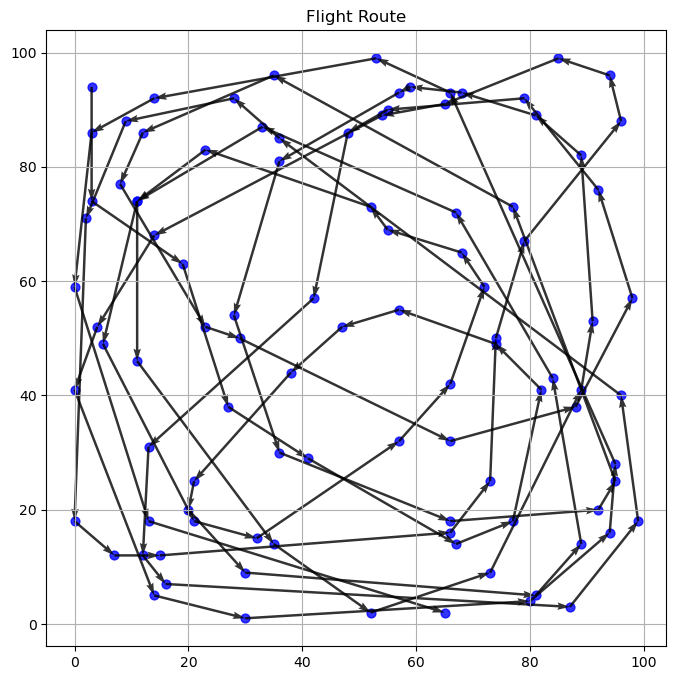 |  
| Best Attempt: $≈122◦$       |



Hopefully this exercise gives you a sense of how a good local search in practice looks like: The evaluation
function should be **informative** and **efficient**. The transition function hasn’t been explored in this solution
– maybe you can try that one out!

Reference: The task is a simplified version of [JOI 2021 – Aerobatics](https://www2.ioi-jp.org/camp/2021/2021-sp-tasks/day1/aerobatics-review.pdf).